<div style="background-color:#f5f5f5; padding:20px; border-radius:10px;">

<h2>Question 3: Customers Who Completed Checkout but Didn't Pay (2022)</h2>

<p><strong>Scenario:</strong></p>

<p>
The Digital Marketing Team wants to identify customers who completed the checkout process 
but did not complete the payment in 2022. This will help them target these customers with 
promotional campaigns.
</p>

<p><strong>Requirements:</strong></p>

<ul>
<li>Filter records where <strong>is_gross = 1</strong> (checkout completed)</li>
<li>Ensure <strong>is_valid = 0</strong> and <strong>is_net = 0</strong> (no successful payment)</li>
<li>Filter data for the year <strong>2022</strong></li>
<li>Retrieve <strong>customer_id</strong> and <strong>registered_date</strong></li>
<li>Remove duplicate customers</li>
</ul>

</div>

In [2]:
import os
import pymysql
import pandas as pd

In [3]:
db_config = {
    "host": "localhost", 
    "user": "root",       
    "password": "baigan",  
    "database": "sales"  
}

In [4]:
output_folder = r"C:\Users\syedm\OneDrive\Desktop\DataNigga" 
os.makedirs(output_folder, exist_ok=True)

In [5]:
queries = {
   'Identifying Customers Who Completed Checkout but Didnt Pay in 2022 Scenario: The Digital Marketing Team wants to identify customers who completed the checkout process but did not make a payment in 2022. This will help them reach out for promotional purposes. Requirements:  Filter the data to find records where is_gross is 1 (indicating completed che Retrieve the customer_id and registered_date for these records. Ensure there are no duplicate customer_id entries.  Share the compiled data with the Marketing Team. Key Features to Use:  is_gross (for checkout status)  is_valid, is_net (to filter invalid or net transactions) order_date (for filtering by year)  customer_id  registered_dateckout but no payment), is_valid is 0, and is_net is 0, for the year 2022.':
   """select distinct
 cusdet.id as customer_id,
cusdet.registered_date
from customer_detail as cusdet
join  order_detail as ordet
on cusdet.id = ordet.customer_id
where ordet.is_gross= 1
and ordet.is_valid= 0
and ordet.is_net=0
and year(order_date)= 2022
order by customer_id desc;
"""
}

In [6]:
from IPython.display import display

In [7]:
try:
    connection = pymysql.connect(**db_config)
    print("Database connection successful!")
    
  
    for question, query in queries.items():
        print(f"\n--- {question} ---")
        df = pd.read_sql(query, connection)
        display(df)  
        
except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Database connection successful!

--- Identifying Customers Who Completed Checkout but Didnt Pay in 2022 Scenario: The Digital Marketing Team wants to identify customers who completed the checkout process but did not make a payment in 2022. This will help them reach out for promotional purposes. Requirements:  Filter the data to find records where is_gross is 1 (indicating completed che Retrieve the customer_id and registered_date for these records. Ensure there are no duplicate customer_id entries.  Share the compiled data with the Marketing Team. Key Features to Use:  is_gross (for checkout status)  is_valid, is_net (to filter invalid or net transactions) order_date (for filtering by year)  customer_id  registered_dateckout but no payment), is_valid is 0, and is_net is 0, for the year 2022. ---


C:\Users\syedm\AppData\Local\Temp\ipykernel_26568\440659664.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,customer_id,registered_date
0,C999472L,2021-07-20
1,C998847L,2022-07-03
2,C998017L,2021-11-14
3,C995819L,2022-07-21
4,C995774L,2022-02-18
...,...,...
815,C115342L,2022-06-17
816,C115129L,2021-11-15
817,C114766L,2022-01-28
818,C110122L,2022-08-14


Database connection closed.


In [8]:
try:
    connection = pymysql.connect(**db_config)
    print("Tin tin Bhai SQL Connected")

  
    query = """
    select distinct
 cusdet.id as customer_id,
cusdet.registered_date
from customer_detail as cusdet
join  order_detail as ordet
on cusdet.id = ordet.customer_id
where ordet.is_gross= 1
and ordet.is_valid= 0
and ordet.is_net=0
and year(order_date)= 2022
order by customer_id desc;

    """

   
    df = pd.read_sql(query, connection)

    
    output_file = os.path.join(output_folder, "checkoutnopay.csv")
    df.to_csv(output_file, index=False)

    print(f"Query result exported to {output_file}")

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Tin tin Bhai SQL Connected
Query result exported to C:\Users\syedm\OneDrive\Desktop\DataNigga\checkoutnopay.csv
Database connection closed.


C:\Users\syedm\AppData\Local\Temp\ipykernel_26568\2906998919.py:22: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


<div style="background-color:#f5f5f5; padding:20px; border-radius:10px;">

<h2>Question 4: Weekend vs Weekday Sales Analysis (Q4 2022)</h2>

<p><strong>Scenario:</strong></p>

<p>
The Campaign Team ran promotional campaigns on weekends (Saturdays and Sundays) 
during October to December 2022. They want to evaluate whether these campaigns 
resulted in higher sales compared to weekdays.
</p>

<p><strong>Objectives:</strong></p>

<ul>
<li>Compare average daily sales between weekends and weekdays</li>
<li>Perform monthly analysis (October, November, December)</li>
<li>Analyze overall performance across the 3-month period</li>
<li>Determine effectiveness of weekend campaigns</li>
</ul>

</div>

In [9]:
queries2= {
   '4. Comparing Weekend and Weekday Sales in Q4 2022 Scenario: The Campaign Team wants to evaluate the effectiveness of their weekend promotional campaigns (Saturdays and Sundays) between October and December 2022 by comparing the average daily sales during weekends vs weekdays. Requirements: 1. Calculate the average daily sales (before_discount) for weekends (Saturdays and Sundays) and weekdays (Monday to Friday) for each month (October, November, and December 2022). 2. Calculate the average sales for weekends vs weekdays for the entire three-month period. 3. Share insights on whether sales increased during weekends. Key Features to Use:  order_date (for filtering by date and identifying days of the week)  before_discount (for sales data)  month_id, month_name, day_name, year (for extracting date-related information)':
   """WITH base_data AS (
    SELECT 
        DATE(order_date) AS order_day,
        MONTH(order_date) AS month_id,
        MONTHNAME(order_date) AS month_name,
        DAYNAME(order_date) AS day_name,
        SUM(before_discount) AS daily_sales
    FROM order_detail
    WHERE 
        is_valid = 1
        AND YEAR(order_date) = 2022
        AND MONTH(order_date) IN (10, 11, 12)
    GROUP BY 
        DATE(order_date),
        MONTH(order_date),
        MONTHNAME(order_date),
        DAYNAME(order_date)
),

classified AS (
    SELECT 
        month_id,
        month_name,
        daily_sales,
        CASE 
            WHEN day_name IN ('Saturday', 'Sunday') THEN 'Weekend'
            ELSE 'Weekday'
        END AS day_type
    FROM base_data
)

-- 🔹 PART 1: Monthly comparison
SELECT 
    month_name,
    day_type,
    ROUND(AVG(daily_sales), 2) AS avg_daily_sales
FROM classified
GROUP BY 
    month_id,
    month_name,
    day_type

UNION ALL

-- 🔹 PART 2: Overall Q4 comparison
SELECT 
    'Overall' AS month_name,
    day_type,
    ROUND(AVG(daily_sales), 2) AS avg_daily_sales
FROM classified
GROUP BY 
    day_type

ORDER BY 
    month_name,
    day_type;
"""
}

In [10]:
try:
    connection = pymysql.connect(**db_config)
    print("Database connection successful!")
    
  
    for question, query in queries2.items():
        print(f"\n--- {question} ---")
        df = pd.read_sql(query, connection)
        display(df)  
        
except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if connection:
        connection.close()
        print("Database connection closed.")

C:\Users\syedm\AppData\Local\Temp\ipykernel_29756\518958027.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


Database connection successful!

--- 4. Comparing Weekend and Weekday Sales in Q4 2022 Scenario: The Campaign Team wants to evaluate the effectiveness of their weekend promotional campaigns (Saturdays and Sundays) between October and December 2022 by comparing the average daily sales during weekends vs weekdays. Requirements: 1. Calculate the average daily sales (before_discount) for weekends (Saturdays and Sundays) and weekdays (Monday to Friday) for each month (October, November, and December 2022). 2. Calculate the average sales for weekends vs weekdays for the entire three-month period. 3. Share insights on whether sales increased during weekends. Key Features to Use:  order_date (for filtering by date and identifying days of the week)  before_discount (for sales data)  month_id, month_name, day_name, year (for extracting date-related information) ---


,month_name,day_type,avg_daily_sales
0,December,Weekday,8411063.33
1,December,Weekend,4105994.00
2,November,Weekday,6204666.00
3,November,Weekend,5774045.00
4,October,Weekday,7793912.40
5,October,Weekend,5708340.67
6,Overall,Weekday,7450819.88
7,Overall,Weekend,5269300.00


Database connection closed.


In [11]:
try:
    connection = pymysql.connect(**db_config)
    print("Tin tin Bhai SQL Connected")

  
    query = """
  WITH base_data AS (
    SELECT 
        DATE(order_date) AS order_day,
        MONTH(order_date) AS month_id,
        MONTHNAME(order_date) AS month_name,
        DAYNAME(order_date) AS day_name,
        SUM(before_discount) AS daily_sales
    FROM order_detail
    WHERE 
        is_valid = 1
        AND YEAR(order_date) = 2022
        AND MONTH(order_date) IN (10, 11, 12)
    GROUP BY 
        DATE(order_date),
        MONTH(order_date),
        MONTHNAME(order_date),
        DAYNAME(order_date)
),

classified AS (
    SELECT 
        month_id,
        month_name,
        daily_sales,
        CASE 
            WHEN day_name IN ('Saturday', 'Sunday') THEN 'Weekend'
            ELSE 'Weekday'
        END AS day_type
    FROM base_data
)

-- 🔹 PART 1: Monthly comparison
SELECT 
    month_name,
    day_type,
    ROUND(AVG(daily_sales), 2) AS avg_daily_sales
FROM classified
GROUP BY 
    month_id,
    month_name,
    day_type

UNION ALL

-- 🔹 PART 2: Overall Q4 comparison
SELECT 
    'Overall' AS month_name,
    day_type,
    ROUND(AVG(daily_sales), 2) AS avg_daily_sales
FROM classified
GROUP BY 
    day_type

ORDER BY 
    month_name,
    day_type;

    """

   
    df = pd.read_sql(query, connection)

    
    output_file = os.path.join(output_folder, "weekday_andend.csv")
    df.to_csv(output_file, index=False)

    print(f"Query result exported to {output_file}")

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Tin tin Bhai SQL Connected
Query result exported to C:\Users\syedm\OneDrive\Desktop\DataNigga\weekday_andend.csv
Database connection closed.


C:\Users\syedm\AppData\Local\Temp\ipykernel_29756\2134497616.py:67: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


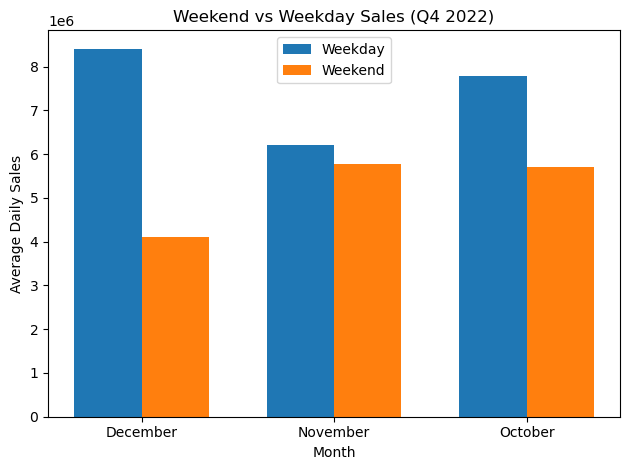

In [12]:
import matplotlib.pyplot as plt
import numpy as np


df_month = df[df["month_name"] != "Overall"]


pivot_df = df_month.pivot(index="month_name", columns="day_type", values="avg_daily_sales")


x = np.arange(len(pivot_df.index))
width = 0.35

plt.figure()


plt.bar(x - width/2, pivot_df["Weekday"], width, label="Weekday")
plt.bar(x + width/2, pivot_df["Weekend"], width, label="Weekend")


plt.xlabel("Month")
plt.ylabel("Average Daily Sales")
plt.title("Weekend vs Weekday Sales (Q4 2022)")
plt.xticks(x, pivot_df.index)

plt.legend()
plt.tight_layout()
plt.show()

<div style="background-color:#f5f5f5; padding:20px; border-radius:10px;">

<h2>Question 5: Products with Largest Decrease in Sales (2021 vs 2022)</h2>

<p><strong>Scenario:</strong></p>

<p>
The Sales Team wants to identify products that experienced the most significant decline 
in sales between 2021 and 2022.
</p>

<p><strong>Objectives:</strong></p>

<ul>
<li>Compare product-level sales between two periods</li>
<li>Calculate sales difference</li>
<li>Identify top 10 products with the highest decline</li>
<li>Visualize the decrease using a bar chart</li>
</ul>

</div>

In [13]:
queries3= {
    '5. Finding Products with the Largest Decrease in Sales Between Two Periods (e.g., 2022 vs 2021) Scenario: The Sales Team would like to identify which products had the most significant decrease in sales between two periods (e.g., 2021 and 2022). Requirements: 1. Create two datasets for each period (e.g., 2021 and 2022), aggregated by product (sku_name). 2. Calculate the sales difference between the two periods. 3. Identify the products with the largest decrease in sales and show the top 10 products. 4. Create a bar chart to visualize the products with the largest decrease in sales. Key Features to Use:  sku_name (for product names)  order_date (for filtering by year) qty_ordered (for sales data)':
       
  """  WITH sale_2021 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2021
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        
        AND YEAR(ordet.order_date) = 2021
    GROUP BY skudet.sku_name
),

sale_2022 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2022
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
      
        AND YEAR(ordet.order_date) = 2022
    GROUP BY skudet.sku_name
)



SELECT 
    COALESCE(a.sku_name, b.sku_name) AS sku_name,
    COALESCE(a.qty_2021, 0) AS qty_2021,
    COALESCE(b.qty_2022, 0) AS qty_2022,
    (COALESCE(a.qty_2021, 0) - COALESCE(b.qty_2022, 0)) AS decrease
FROM sale_2021 a
LEFT JOIN sale_2022 b
    ON a.sku_name = b.sku_name
WHERE 
    (COALESCE(a.qty_2021, 0) - COALESCE(b.qty_2022, 0)) > 0
ORDER BY decrease DESC
LIMIT 10;
"""
}


In [14]:
try:
    connection = pymysql.connect(**db_config)
    print("Database connection successful!")
    
  
    for question, query in queries3.items():
        print(f"\n--- {question} ---")
        df = pd.read_sql(query, connection)
        display(df)  
        
except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Database connection successful!

--- 5. Finding Products with the Largest Decrease in Sales Between Two Periods (e.g., 2022 vs 2021) Scenario: The Sales Team would like to identify which products had the most significant decrease in sales between two periods (e.g., 2021 and 2022). Requirements: 1. Create two datasets for each period (e.g., 2021 and 2022), aggregated by product (sku_name). 2. Calculate the sales difference between the two periods. 3. Identify the products with the largest decrease in sales and show the top 10 products. 4. Create a bar chart to visualize the products with the largest decrease in sales. Key Features to Use:  sku_name (for product names)  order_date (for filtering by year) qty_ordered (for sales data) ---


C:\Users\syedm\AppData\Local\Temp\ipykernel_29756\2649141385.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,sku_name,qty_2021,qty_2022,decrease
0,RB_Dettol Germ Busting Kit-bf,400.0,80.0,320.0
1,RS_Plain Rusk,320.0,0.0,320.0
2,RB_Household Bundle,226.0,0.0,226.0
3,RS_Baklawa 500gm,214.0,36.0,178.0
4,RS_Honey Dry Fruit Halwa,104.0,0.0,104.0
5,CA_shirt-Small,100.0,0.0,100.0
6,RS_Soan Papri-250gm,102.0,14.0,88.0
7,jn_900g,104.0,20.0,84.0
8,Mardaz_MDZ-P-18-M,68.0,0.0,68.0
9,Topline_Waheed Murad His Life and Our Times,82.0,20.0,62.0


Database connection closed.


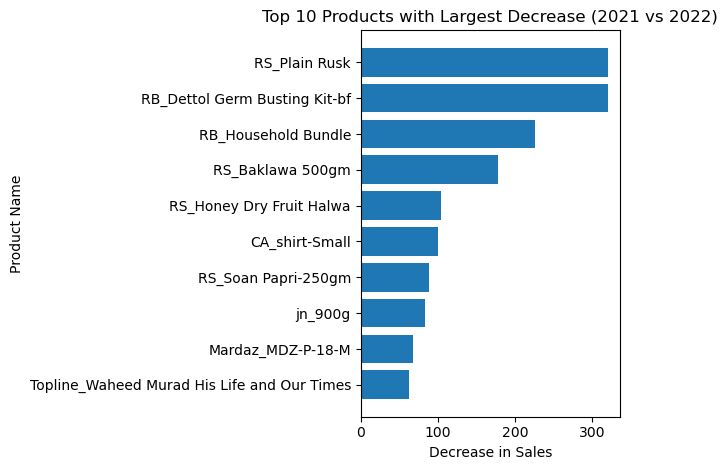

In [15]:
import matplotlib.pyplot as plt

df_sorted = df.sort_values(by="decrease")

plt.figure()

plt.barh(df_sorted["sku_name"], df_sorted["decrease"])

plt.xlabel("Decrease in Sales")
plt.ylabel("Product Name")
plt.title("Top 10 Products with Largest Decrease (2021 vs 2022)")

plt.tight_layout()

plt.show()

In [16]:
try:
    connection = pymysql.connect(**db_config)
    print("Tin tin Bhai SQL Connected")

  
    query = """
    
    WITH sale_2021 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2021
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        
        AND YEAR(ordet.order_date) = 2021
    GROUP BY skudet.sku_name
),

sale_2022 AS (
    SELECT 
        skudet.sku_name,
        SUM(ordet.qty_ordered) AS qty_2022
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
      
        AND YEAR(ordet.order_date) = 2022
    GROUP BY skudet.sku_name
)



SELECT 
    COALESCE(a.sku_name, b.sku_name) AS sku_name,
    COALESCE(a.qty_2021, 0) AS qty_2021,
    COALESCE(b.qty_2022, 0) AS qty_2022,
    (COALESCE(a.qty_2021, 0) - COALESCE(b.qty_2022, 0)) AS decrease
FROM sale_2021 a
LEFT JOIN sale_2022 b
    ON a.sku_name = b.sku_name
WHERE 
    (COALESCE(a.qty_2021, 0) - COALESCE(b.qty_2022, 0)) > 0
ORDER BY decrease DESC
LIMIT 10;

    """

   
    df = pd.read_sql(query, connection)

    
    output_file = os.path.join(output_folder, "top10productdecrease.csv")
    df.to_csv(output_file, index=False)

    print(f"Query result exported to {output_file}")

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Tin tin Bhai SQL Connected
Query result exported to C:\Users\syedm\OneDrive\Desktop\DataNigga\top10productdecrease.csv
Database connection closed.


C:\Users\syedm\AppData\Local\Temp\ipykernel_29756\278036598.py:54: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


<div style="background-color:#f5f5f5; padding:20px; border-radius:10px;">

<h2>Question 6: Sales Trends Comparison Across Categories (2022)</h2>

<p><strong>Scenario:</strong></p>

<p>
The Marketing Team wants to analyze sales trends across different product categories in 2022 
to identify which category performed the best.
</p>

<p><strong>Objectives:</strong></p>

<ul>
<li>Aggregate sales data by category</li>
<li>Analyze monthly sales trends</li>
<li>Compare category performance over time</li>
<li>Identify the category with the highest growth</li>
</ul>

</div>

In [17]:
queries4= {
    '6. Comparing Sales Trends for Multiple Categories in 2022 Scenario: The Marketing Team wants to compare the sales trends for multiple categories in 2022 to identify which category performed best. Requirements: 1. Aggregate the sales data by category for 2022. 2. Plot a time series of sales trends for each category (use order_date to group by month or week). 3. Provide insights on which category had the highest sales growth. Key Features to Use: category order_date (for time series analysis)  qty_ordered':
       
  """ WITH monthly_sales AS (
    SELECT 
        skudet.category,
        MONTH(order_date) AS month_id,
        MONTHNAME(order_date) AS month_name,
        SUM(ordet.qty_ordered) AS total_sales
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        AND YEAR(ordet.order_date) = 2022
    GROUP BY 
        skudet.category,
        MONTH(order_date),
        MONTHNAME(order_date)
)

SELECT *
FROM monthly_sales
ORDER BY category, month_id;
"""
}


In [18]:
try:
    connection = pymysql.connect(**db_config)
    print("Database connection successful!")
    
  
    for question, query in queries4.items():
        print(f"\n--- {question} ---")
        df = pd.read_sql(query, connection)
        display(df)  
        
except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Database connection successful!

--- 6. Comparing Sales Trends for Multiple Categories in 2022 Scenario: The Marketing Team wants to compare the sales trends for multiple categories in 2022 to identify which category performed best. Requirements: 1. Aggregate the sales data by category for 2022. 2. Plot a time series of sales trends for each category (use order_date to group by month or week). 3. Provide insights on which category had the highest sales growth. Key Features to Use: category order_date (for time series analysis)  qty_ordered ---


C:\Users\syedm\AppData\Local\Temp\ipykernel_29756\4257187566.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,category,month_id,month_name,total_sales
0,Appliances,1,January,40.0
1,Appliances,2,February,46.0
2,Appliances,3,March,36.0
3,Appliances,4,April,28.0
4,Appliances,5,May,26.0
...,...,...,...,...
175,Women Fashion,8,August,12.0
176,Women Fashion,9,September,14.0
177,Women Fashion,10,October,6.0
178,Women Fashion,11,November,10.0


Database connection closed.


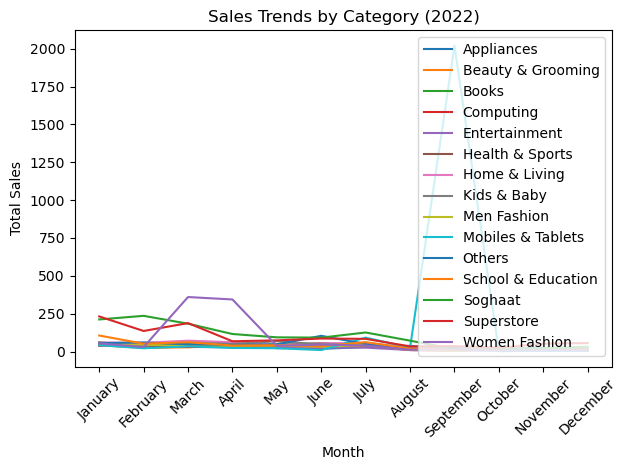

In [19]:
import matplotlib.pyplot as plt


pivot_df = df.pivot(index="month_name", columns="category", values="total_sales")


month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

pivot_df = pivot_df.reindex(month_order)

plt.figure()

for col in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[col], label=col)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.title("Sales Trends by Category (2022)")

plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
try:
    connection = pymysql.connect(**db_config)
    print("Tin tin Bhai SQL Connected")

  
    query = """
    
    WITH monthly_sales AS (
    SELECT 
        skudet.category,
        MONTH(order_date) AS month_id,
        MONTHNAME(order_date) AS month_name,
        SUM(ordet.qty_ordered) AS total_sales
    FROM order_detail ordet
    JOIN sku_detail skudet 
        ON ordet.sku_id = skudet.id
    WHERE 
        ordet.is_valid = 1
        AND YEAR(ordet.order_date) = 2022
    GROUP BY 
        skudet.category,
        MONTH(order_date),
        MONTHNAME(order_date)
)

SELECT *
FROM monthly_sales
ORDER BY category, month_id;

    """

   
    df = pd.read_sql(query, connection)

    
    output_file = os.path.join(output_folder, "timeseries.csv")
    df.to_csv(output_file, index=False)

    print(f"Query result exported to {output_file}")

except Exception as e:
    print(f"An error occurred: {e}")

finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Tin tin Bhai SQL Connected
Query result exported to C:\Users\syedm\OneDrive\Desktop\DataNigga\timeseries.csv
Database connection closed.


C:\Users\syedm\AppData\Local\Temp\ipykernel_29756\2032963300.py:33: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)
